Loading Training Data...
Input Shape for Hybrid Model: (73651, 11, 1)

--- Training CNN Stage ---
Epoch 1/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.1535 - mae: 0.2781 - val_loss: 0.1457 - val_mae: 0.2831
Epoch 2/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.1350 - mae: 0.2596 - val_loss: 0.1297 - val_mae: 0.2610
Epoch 3/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.1264 - mae: 0.2508 - val_loss: 0.1212 - val_mae: 0.2494
Epoch 4/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.1197 - mae: 0.2447 - val_loss: 0.1136 - val_mae: 0.2403
Epoch 5/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.1146 - mae: 0.2396 - val_loss: 0.1132 - val_mae: 0.2402
Epoch 6/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.1105 - mae: 0.2358 - val_loss: 0.1107 - val_mae: 0.2434
Epoch 7/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.1077 - mae: 0.2330 - val_loss: 0.1157 - val_mae: 0.2496
Epoch 8/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 12s 5

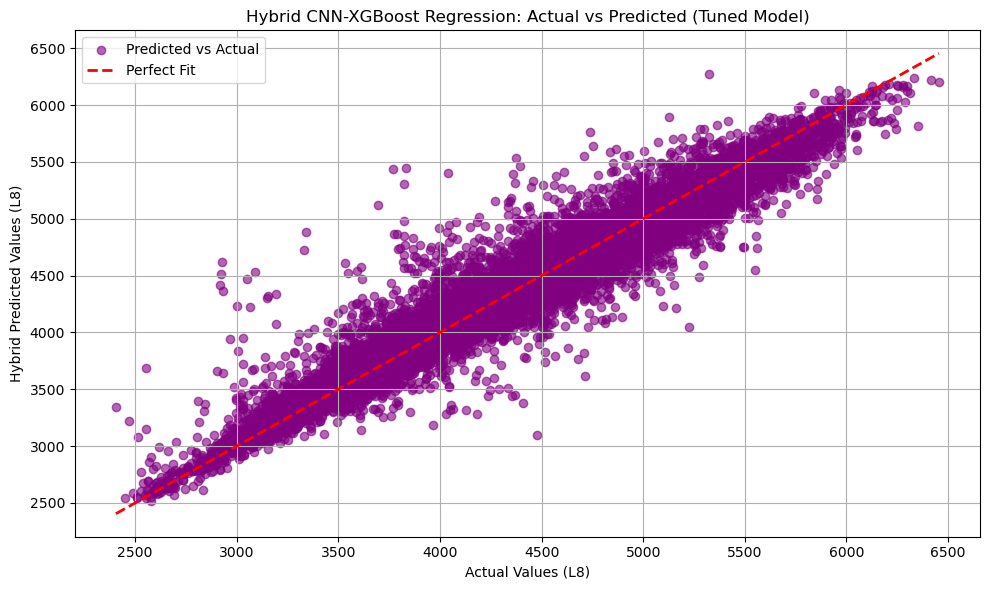


SAVING TRAINED MODELS AND SCALERS
✓ CNN feature extractor saved to 'cnn_feature_extractor.h5'
✓ XGBoost model saved to 'xgb_model.pkl'
✓ X scaler saved to 'x_scaler.pkl'
✓ Y scaler saved to 'y_scaler.pkl'

✓ Training pipeline complete!

STARTING TESTING PIPELINE
Loading trained models and scalers...
Loading new test data from 2025_testing.xlsx...
✓ Target variable 'L8' found - will evaluate performance
✓ Predictions saved to '2025_testing_predictions.xlsx'

--- New Data Evaluation (2025) ---
RMSE: 375.3521
MAE : 270.1390
R2  : 0.6703
MAPE: 4.8838%


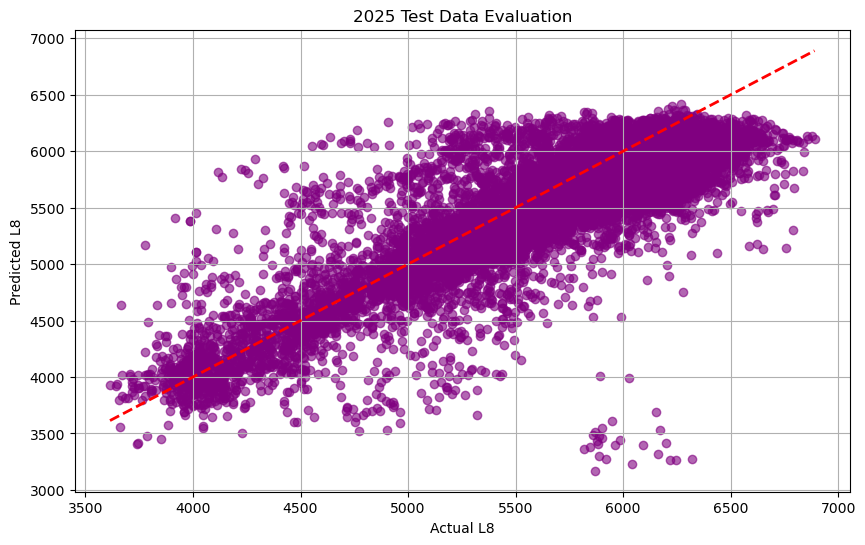

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor

# Replaced RandomizedSearchCV/scipy imports with skopt (Bayesian Optimization)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import pickle
import joblib
import os

# ===============================
#  HELPER FUNCTIONS
# ===============================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # avoid division by zero
    epsilon = 1e-7
    y_true = np.where(y_true == 0, epsilon, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def run_training_pipeline():
    # ==========================================
    # 1. DATA LOADING & PREPROCESSING
    # ==========================================
    print("Loading Training Data...")
    try:
        df = pd.read_excel("Feature_engineering_DS.xlsx")
    except FileNotFoundError:
        print("Error: File 'Feature_engineering_DS.xlsx' not found.")
        return

    X = df.drop(["L8", "date"], axis=1, errors='ignore').values
    y = df["L8"].values.reshape(-1, 1)

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_s = x_scaler.fit_transform(X_train)
    y_train_s = y_scaler.fit_transform(y_train)
    X_val_s = x_scaler.transform(X_val)
    y_val_s = y_scaler.transform(y_val)
    X_test_s = x_scaler.transform(X_test)
    y_test_s = y_scaler.transform(y_test)

    # Reshape for CNN [samples, time steps, features]
    X_train_cnn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
    X_val_cnn = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)
    X_test_cnn = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

    print(f"Input Shape for Hybrid Model: {X_train_cnn.shape}")

    # ==========================================
    # 2. TRAIN CNN (Feature Extractor Stage)
    # ==========================================
    print("\n--- Training CNN Stage ---")

    inputs = Input(shape=(X_train_cnn.shape[1], 1))
    x = Conv1D(filters=64, kernel_size=2, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Conv1D(filters=32, kernel_size=2, activation='relu')(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    # Feature extraction layer
    features = Dense(32, activation='relu', name='feature_layer')(x)
    outputs = Dense(1, activation='linear')(features)

    cnn_model = Model(inputs=inputs, outputs=outputs)

    optimizer = Adam(learning_rate=0.001)
    cnn_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    cnn_model.fit(
        X_train_cnn, y_train_s,
        validation_data=(X_val_cnn, y_val_s),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # ==========================================
    # 3. HYBRIDIZATION (Feature Extraction)
    # ==========================================
    print("\n--- Extracting Features from CNN for XGBoost ---")

    feature_extractor = Model(inputs=inputs, outputs=features)

    X_train_features = feature_extractor.predict(X_train_cnn)
    X_val_features = feature_extractor.predict(X_val_cnn)
    X_test_features = feature_extractor.predict(X_test_cnn)

    print(f"New Feature Shape for XGBoost: {X_train_features.shape}")

    # Combine Train and Val for Bayesian Search
    X_train_val_features = np.vstack([X_train_features, X_val_features])
    y_train_val_s = np.vstack([y_train_s, y_val_s])

    # ==========================================
    # 4. HYPERPARAMETER TUNING (BAYESIAN SEARCH)
    # ==========================================
    print("\n--- Performing BayesSearchCV for XGBoost Hyperparameter Tuning ---")

    # Define the search space using skopt types
    # Note: Bounds are matched to your previous scipy distributions
    search_spaces = {
        'n_estimators': Integer(800, 1500),
        'learning_rate': Real(0.02, 0.08, prior='uniform'),
        'max_depth': Categorical([6, 7, 8, 9]),
        'min_child_weight': Integer(1, 3), # Inclusive in skopt
        'subsample': Real(0.70, 0.95, prior='uniform'),
        'colsample_bytree': Real(0.70, 0.95, prior='uniform'),
        'gamma': Real(0.0, 0.2, prior='uniform')
    }

    xgb_base = XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    )

    # Initialize BayesSearchCV
    # Note: n_iter is set to 50 as Bayesian Search converges much faster than Random Search
    bayes_search = BayesSearchCV(
        estimator=xgb_base,
        search_spaces=search_spaces,
        n_iter=50, 
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print("Starting optimized hyperparameter search (Bayesian Search)... This may take a while.")
    bayes_search.fit(X_train_val_features, y_train_val_s.ravel())

    xgb_model = bayes_search.best_estimator_

    print("\n--- Best Optimized Hyperparameters Found ---")
    for param, value in bayes_search.best_params_.items():
        print(f"{param}: {value}")
    print(f"\nBest CV Score (Neg MSE): {bayes_search.best_score_:.4f}")

    # ==========================================
    # 5. EVALUATION ON TEST SET
    # ==========================================
    print("\n--- Evaluating Best Model on Test Set ---")

    pred_s = xgb_model.predict(X_test_features).reshape(-1, 1)

    pred_real = y_scaler.inverse_transform(pred_s)
    y_test_real = y_scaler.inverse_transform(y_test_s)

    rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
    mae = mean_absolute_error(y_test_real, pred_real)
    mse = mean_squared_error(y_test_real, pred_real)
    r2 = r2_score(y_test_real, pred_real)
    mape = mean_absolute_percentage_error(y_test_real, pred_real)

    print("\n--- Hybrid CNN-XGBoost Model Results (After Tuning) ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"R2  : {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    # ==========================================
    # 6. VISUALIZATION
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_real, pred_real, alpha=0.6, color='purple', label='Predicted vs Actual')
    plt.plot([y_test_real.min(), y_test_real.max()],
             [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel("Actual Values (L8)")
    plt.ylabel("Hybrid Predicted Values (L8)")
    plt.title("Hybrid CNN-XGBoost Regression: Actual vs Predicted (Tuned Model)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('training_results.png')
    plt.show()

    # ==========================================
    # 7. SAVING MODELS
    # ==========================================
    print("\n" + "="*60)
    print("SAVING TRAINED MODELS AND SCALERS")
    print("="*60)

    feature_extractor.save('cnn_feature_extractor.h5')
    print("✓ CNN feature extractor saved to 'cnn_feature_extractor.h5'")

    joblib.dump(xgb_model, 'xgb_model.pkl')
    print("✓ XGBoost model saved to 'xgb_model.pkl'")

    with open('x_scaler.pkl', 'wb') as f:
        pickle.dump(x_scaler, f)
    print("✓ X scaler saved to 'x_scaler.pkl'")

    with open('y_scaler.pkl', 'wb') as f:
        pickle.dump(y_scaler, f)
    print("✓ Y scaler saved to 'y_scaler.pkl'")

    print("\n✓ Training pipeline complete!")


def run_testing_pipeline():
    # ==========================================
    # 8. TESTING ON NEW DATA
    # ==========================================
    print("\n" + "="*60)
    print("STARTING TESTING PIPELINE")
    print("="*60)
    
    print("Loading trained models and scalers...")
    
    if not os.path.exists('cnn_feature_extractor.h5'):
        print("Error: Models not found. Please run training first.")
        return

    feature_extractor = load_model('cnn_feature_extractor.h5')
    xgb_model = joblib.load('xgb_model.pkl')
    
    with open('x_scaler.pkl', 'rb') as f:
        x_scaler = pickle.load(f)
    with open('y_scaler.pkl', 'rb') as f:
        y_scaler = pickle.load(f)

    print("Loading new test data from 2025_testing.xlsx...")
    try:
        df_test = pd.read_excel("2025_testing.xlsx")
    except FileNotFoundError:
        print("Error: File '2025_testing.xlsx' not found.")
        return

    # Determine if we have targets or just features
    has_target = 'L8' in df_test.columns

    if has_target:
        X_new = df_test.drop(["L8", "date"], axis=1, errors='ignore').values
        y_new = df_test["L8"].values.reshape(-1, 1)
        print("✓ Target variable 'L8' found - will evaluate performance")
    else:
        X_new = df_test.drop(["date"], axis=1, errors='ignore').values
        y_new = None
        print("✓ No target variable found - will only generate predictions")

    # Preprocess
    X_new_scaled = x_scaler.transform(X_new)
    X_new_cnn = X_new_scaled.reshape(X_new_scaled.shape[0], X_new_scaled.shape[1], 1)

    # Inference
    X_new_features = feature_extractor.predict(X_new_cnn, verbose=0)
    pred_scaled = xgb_model.predict(X_new_features).reshape(-1, 1)
    predictions = y_scaler.inverse_transform(pred_scaled)

    # Save Results
    results_df = df_test.copy()
    results_df['Predicted_L8'] = predictions
    results_df.to_excel('2025_testing_predictions.xlsx', index=False)
    print("✓ Predictions saved to '2025_testing_predictions.xlsx'")

    # Evaluation
    if has_target:
        rmse = np.sqrt(mean_squared_error(y_new, predictions))
        mae = mean_absolute_error(y_new, predictions)
        r2 = r2_score(y_new, predictions)
        
        # Calc MAPE avoiding div by zero
        non_zero_mask = y_new != 0
        if np.sum(non_zero_mask) > 0:
            mape = np.mean(np.abs((y_new[non_zero_mask] - predictions[non_zero_mask]) / y_new[non_zero_mask])) * 100
        else:
            mape = np.nan

        print("\n--- New Data Evaluation (2025) ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE : {mae:.4f}")
        print(f"R2  : {r2:.4f}")
        print(f"MAPE: {mape:.4f}%")

        plt.figure(figsize=(10, 6))
        plt.scatter(y_new, predictions, alpha=0.6, color='purple')
        plt.plot([y_new.min(), y_new.max()], [y_new.min(), y_new.max()], 'r--', lw=2)
        plt.xlabel("Actual L8")
        plt.ylabel("Predicted L8")
        plt.title("2025 Test Data Evaluation")
        plt.grid(True)
        plt.savefig('test_results_2025.png')
        plt.show()

if __name__ == "__main__":
    # 1. Run Training (including BayesSearchCV)
    run_training_pipeline()
    
    # 2. Run Testing (on new 2025 data)
    run_testing_pipeline()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# SHORTCUT: LOAD & PLOT GRAPHS
# ==========================================

print("Loading saved files...")

# 1. Load Data
try:
    df_train = pd.read_excel("Feature_engineering_DS.xlsx")
    df_test = pd.read_excel("2025_jan.xlsx")
    
    # Ensure dates are treated as actual datetime objects
    if 'date' in df_train.columns:
        df_train['date'] = pd.to_datetime(df_train['date'])
        # --- FIX: Sort training data by date to prevent "spaghetti" lines ---
        df_train = df_train.sort_values(by='date').reset_index(drop=True)
        
    if 'date' in df_test.columns:
        df_test['date'] = pd.to_datetime(df_test['date'])
        # --- FIX: Sort testing data by date ---
        df_test = df_test.sort_values(by='date').reset_index(drop=True)
        
except FileNotFoundError:
    print("Error: Excel data files not found in directory.")
    exit()

# 2. Load Models & Scalers
try:
    feature_extractor = load_model('cnn_feature_extractor.h5')
    xgb_model = joblib.load('xgb_model.pkl')
    with open('x_scaler.pkl', 'rb') as f:
        x_scaler = pickle.load(f)
    with open('y_scaler.pkl', 'rb') as f:
        y_scaler = pickle.load(f)
    print("✓ Models and Scalers loaded successfully.")
except FileNotFoundError:
    print("Error: Model files (h5/pkl) not found. Did the training finish successfully?")
    exit()

# 3. Helper function to generate predictions
def predict_load(data):
    # Drop target and date to isolate features
    X = data.drop(["L8", "date"], axis=1, errors='ignore').values
    
    # Scale and reshape for CNN
    X_scaled = x_scaler.transform(X)
    X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
    
    # Extract features & Predict
    cnn_features = feature_extractor.predict(X_cnn, verbose=0)
    pred_scaled = xgb_model.predict(cnn_features).reshape(-1, 1)
    
    # Return inverse transformed (real scale) predictions
    return y_scaler.inverse_transform(pred_scaled)

print("Generating predictions...")
train_preds = predict_load(df_train)
test_preds = predict_load(df_test)

# 4. Plotting
plt.figure(figsize=(18, 6))

# --- Plot 1: Training Data (Load vs Time) ---
plt.subplot(1, 2, 1)
x_axis_train = df_train['date'] if 'date' in df_train.columns else range(len(df_train))

plt.plot(x_axis_train, df_train['L8'], label='Actual Load', color='#1f77b4', alpha=0.6)
plt.plot(x_axis_train, train_preds, label='Predicted Load', color='orange', alpha=0.8, linewidth=1)
plt.title('Training Data: Load vs Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Load (L8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45) 

# --- Plot 2: Testing Data (Load vs Time) ---
plt.subplot(1, 2, 2)
x_axis_test = df_test['date'] if 'date' in df_test.columns else range(len(df_test))

if 'L8' in df_test.columns:
    plt.plot(x_axis_test, df_test['L8'], label='Actual Load', color='#1f77b4', alpha=0.6)
    
plt.plot(x_axis_test, test_preds, label='Predicted Load', color='green', alpha=0.8, linewidth=1)
plt.title('Testing Data: Load vs Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Load (L8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("✓ Graphs generated.")

# 5. Metric Calculation Logic
def calculate_metrics(y_true, y_pred, label="Data"):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n--- Evaluation Metrics: {label} ---")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R2:    {r2:.4f}")
    print(f"MAPE:  {mape:.4f}%")

# Generate metrics for Training Set
calculate_metrics(df_train['L8'], train_preds, "Training Set")

# Generate metrics for Testing Set (only if target exists)
if 'L8' in df_test.columns:
    calculate_metrics(df_test['L8'], test_preds, "Testing Set")
else:
    print("\nNote: Testing metrics skipped because target 'L8' is missing in test file.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# SHORTCUT: LOAD & PLOT GRAPHS
# ==========================================

print("Loading saved files...")

# 1. Load Data
try:
    df_train = pd.read_excel("Feature_engineering_DS.xlsx")
    df_test = pd.read_excel("feb_testing.xlsx")
    
    # Ensure dates are treated as actual datetime objects
    if 'date' in df_train.columns:
        df_train['date'] = pd.to_datetime(df_train['date'])
        # --- FIX: Sort training data by date to prevent "spaghetti" lines ---
        df_train = df_train.sort_values(by='date').reset_index(drop=True)
        
    if 'date' in df_test.columns:
        df_test['date'] = pd.to_datetime(df_test['date'])
        # --- FIX: Sort testing data by date ---
        df_test = df_test.sort_values(by='date').reset_index(drop=True)
        
except FileNotFoundError:
    print("Error: Excel data files not found in directory.")
    exit()

# 2. Load Models & Scalers
try:
    feature_extractor = load_model('cnn_feature_extractor.h5')
    xgb_model = joblib.load('xgb_model.pkl')
    with open('x_scaler.pkl', 'rb') as f:
        x_scaler = pickle.load(f)
    with open('y_scaler.pkl', 'rb') as f:
        y_scaler = pickle.load(f)
    print("✓ Models and Scalers loaded successfully.")
except FileNotFoundError:
    print("Error: Model files (h5/pkl) not found. Did the training finish successfully?")
    exit()

# 3. Helper function to generate predictions
def predict_load(data):
    # Drop target and date to isolate features
    X = data.drop(["L8", "date"], axis=1, errors='ignore').values
    
    # Scale and reshape for CNN
    X_scaled = x_scaler.transform(X)
    X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
    
    # Extract features & Predict
    cnn_features = feature_extractor.predict(X_cnn, verbose=0)
    pred_scaled = xgb_model.predict(cnn_features).reshape(-1, 1)
    
    # Return inverse transformed (real scale) predictions
    return y_scaler.inverse_transform(pred_scaled)

print("Generating predictions...")
train_preds = predict_load(df_train)
test_preds = predict_load(df_test)

# 4. Plotting
plt.figure(figsize=(18, 6))

# --- Plot 1: Training Data (Load vs Time) ---
plt.subplot(1, 2, 1)
x_axis_train = df_train['date'] if 'date' in df_train.columns else range(len(df_train))

plt.plot(x_axis_train, df_train['L8'], label='Actual Load', color='#1f77b4', alpha=0.6)
plt.plot(x_axis_train, train_preds, label='Predicted Load', color='orange', alpha=0.8, linewidth=1)
plt.title('Training Data: Load vs Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Load (L8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45) 

# --- Plot 2: Testing Data (Load vs Time) ---
plt.subplot(1, 2, 2)
x_axis_test = df_test['date'] if 'date' in df_test.columns else range(len(df_test))

if 'L8' in df_test.columns:
    plt.plot(x_axis_test, df_test['L8'], label='Actual Load', color='#1f77b4', alpha=0.6)
    
plt.plot(x_axis_test, test_preds, label='Predicted Load', color='green', alpha=0.8, linewidth=1)
plt.title('Testing Data: Load vs Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Load (L8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("✓ Graphs generated.")

# 5. Metric Calculation Logic
def calculate_metrics(y_true, y_pred, label="Data"):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n--- Evaluation Metrics: {label} ---")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R2:    {r2:.4f}")
    print(f"MAPE:  {mape:.4f}%")

# Generate metrics for Training Set
calculate_metrics(df_train['L8'], train_preds, "Training Set")

# Generate metrics for Testing Set (only if target exists)
if 'L8' in df_test.columns:
    calculate_metrics(df_test['L8'], test_preds, "Testing Set")
else:
    print("\nNote: Testing metrics skipped because target 'L8' is missing in test file.")

Loading saved files...


C:\Users\HP\AppData\Local\Temp\ipykernel_1828\1975220326.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train['date'] = pd.to_datetime(df_train['date'])


✓ Models and Scalers loaded successfully.
Generating predictions...


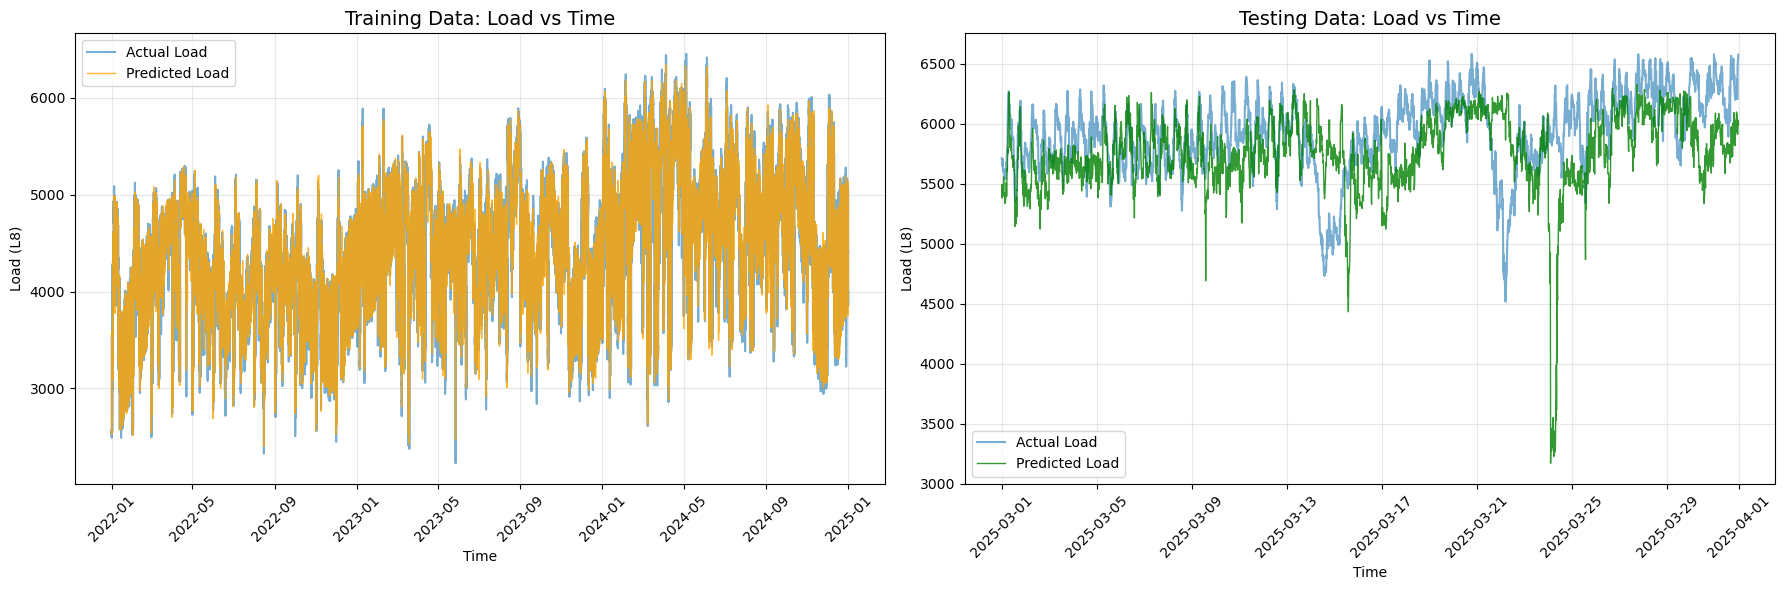

✓ Graphs generated.

--- Evaluation Metrics: Training Set ---
MAE:   73.9318
RMSE:  110.8804
R2:    0.9733
MAPE:  1.7265%

--- Evaluation Metrics: Testing Set ---
MAE:   314.9979
RMSE:  443.0017
R2:    -0.8500
MAPE:  5.3841%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# SHORTCUT: LOAD & PLOT GRAPHS
# ==========================================

print("Loading saved files...")

# 1. Load Data
try:
    df_train = pd.read_excel("Feature_engineering_DS.xlsx")
    df_test = pd.read_excel("2025_march.xlsx")
    
    # Ensure dates are treated as actual datetime objects
    if 'date' in df_train.columns:
        df_train['date'] = pd.to_datetime(df_train['date'])
        # --- FIX: Sort training data by date to prevent "spaghetti" lines ---
        df_train = df_train.sort_values(by='date').reset_index(drop=True)
        
    if 'date' in df_test.columns:
        df_test['date'] = pd.to_datetime(df_test['date'])
        # --- FIX: Sort testing data by date ---
        df_test = df_test.sort_values(by='date').reset_index(drop=True)
        
except FileNotFoundError:
    print("Error: Excel data files not found in directory.")
    exit()

# 2. Load Models & Scalers
try:
    feature_extractor = load_model('cnn_feature_extractor.h5')
    xgb_model = joblib.load('xgb_model.pkl')
    with open('x_scaler.pkl', 'rb') as f:
        x_scaler = pickle.load(f)
    with open('y_scaler.pkl', 'rb') as f:
        y_scaler = pickle.load(f)
    print("✓ Models and Scalers loaded successfully.")
except FileNotFoundError:
    print("Error: Model files (h5/pkl) not found. Did the training finish successfully?")
    exit()

# 3. Helper function to generate predictions
def predict_load(data):
    # Drop target and date to isolate features
    X = data.drop(["L8", "date"], axis=1, errors='ignore').values
    
    # Scale and reshape for CNN
    X_scaled = x_scaler.transform(X)
    X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
    
    # Extract features & Predict
    cnn_features = feature_extractor.predict(X_cnn, verbose=0)
    pred_scaled = xgb_model.predict(cnn_features).reshape(-1, 1)
    
    # Return inverse transformed (real scale) predictions
    return y_scaler.inverse_transform(pred_scaled)

print("Generating predictions...")
train_preds = predict_load(df_train)
test_preds = predict_load(df_test)

# 4. Plotting
plt.figure(figsize=(18, 6))

# --- Plot 1: Training Data (Load vs Time) ---
plt.subplot(1, 2, 1)
x_axis_train = df_train['date'] if 'date' in df_train.columns else range(len(df_train))

plt.plot(x_axis_train, df_train['L8'], label='Actual Load', color='#1f77b4', alpha=0.6)
plt.plot(x_axis_train, train_preds, label='Predicted Load', color='orange', alpha=0.8, linewidth=1)
plt.title('Training Data: Load vs Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Load (L8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45) 

# --- Plot 2: Testing Data (Load vs Time) ---
plt.subplot(1, 2, 2)
x_axis_test = df_test['date'] if 'date' in df_test.columns else range(len(df_test))

if 'L8' in df_test.columns:
    plt.plot(x_axis_test, df_test['L8'], label='Actual Load', color='#1f77b4', alpha=0.6)
    
plt.plot(x_axis_test, test_preds, label='Predicted Load', color='green', alpha=0.8, linewidth=1)
plt.title('Testing Data: Load vs Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Load (L8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("✓ Graphs generated.")

# 5. Metric Calculation Logic
def calculate_metrics(y_true, y_pred, label="Data"):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n--- Evaluation Metrics: {label} ---")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R2:    {r2:.4f}")
    print(f"MAPE:  {mape:.4f}%")

# Generate metrics for Training Set
calculate_metrics(df_train['L8'], train_preds, "Training Set")

# Generate metrics for Testing Set (only if target exists)
if 'L8' in df_test.columns:
    calculate_metrics(df_test['L8'], test_preds, "Testing Set")
else:
    print("\nNote: Testing metrics skipped because target 'L8' is missing in test file.")